# ADARP: preprocessing and dataset validation

The data loading lives in `load_adarp.py` and everything that turns those
recordings into labelled windows lives in `preprocess_adarp_data.py`. This
notebook drives those two modules and keeps the diagnostics: what the tags look
like, how many windows each participant contributes, and how skewed the classes
are.

Label construction follows the original ADARP work:

- **stress** — a 40 min segment centred on each usable button press (±20 min)
- **non-stress** — spans that open only once a press's whole ±60 min window has
  gone by, and that stay 60 min clear of every other press

Each segment is cut independently into 60 s windows with a 30 s stride, on a
fixed grid, and any window two segments both claim is kept once. One press
yields at most 79 windows — model examples from a single human annotation, not
79 annotations.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import load_adarp as adarp
import preprocess_adarp_data as prep

PARTICIPANTS = adarp.participant_ids()
PARTICIPANTS

['101C',
 '102C',
 '104C',
 '105C',
 '106C',
 '107C',
 '108C',
 '109C',
 '110C',
 '111C',
 '112C']

## 1. Load every participant's EDA and HR at their native rates

In [2]:
df = adarp.load_all_participants()

print(df.shape)
print(df["participant"].nunique(), "participants,", df["session"].nunique(), "sessions")
print(f"{df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

# df is sorted by time and nobody overlaps, so head() only ever shows 101
print("\nrows per participant:")
print(df["participant"].value_counts().sort_index().to_string())

df.head()

(24365765, 4)
11 participants, 236 sessions
0.66 GB

rows per participant:
101    1608741
102    2862788
104    1892902
105    2426133
106    2953596
107    2603147
108    1360014
109    1555116
110    2141175
111    2190659
112    2771494


,participant,eda,hr,session
timestamp,,,,
2019-04-26 18:48:29+00:00,101,0.002562,56.0,A01fb9_190426-184819
2019-04-26 18:48:29.249999872+00:00,101,0.003843,NaN,A01fb9_190426-184819
2019-04-26 18:48:29.500000+00:00,101,0.003843,NaN,A01fb9_190426-184819
2019-04-26 18:48:29.750000128+00:00,101,0.003843,NaN,A01fb9_190426-184819
2019-04-26 18:48:30+00:00,101,0.002562,52.5,A01fb9_190426-184819


## 2. Button presses, and which of them can carry a stress segment

A press is *usable* when the tag instant sits inside both signals, and has
*full context* when the whole ±20 min segment does. Only the second kind
becomes a stress event.

In [3]:
tags_by_participant = {
    participant.rstrip("C"): adarp.load_tags(participant)
    for participant in PARTICIPANTS
}

for participant_id, tags in tags_by_participant.items():
    print(f"{participant_id}: {len(tags):3d} tags across "
          f"{tags.attrs['sessions_with_tags']:3d} sessions, "
          f"{len(tags.attrs['empty_sessions']):3d} sessions with none")

101:  19 tags across  15 sessions,   9 sessions with none
102:  86 tags across  27 sessions,   5 sessions with none
104:  22 tags across  19 sessions,   0 sessions with none
105:  32 tags across  16 sessions,  11 sessions with none
106:  28 tags across  20 sessions,   6 sessions with none
107:  22 tags across  20 sessions,   4 sessions with none
108:  24 tags across  11 sessions,   0 sessions with none
109:  40 tags across  18 sessions,   0 sessions with none
110:  26 tags across  14 sessions,   6 sessions with none
111:  49 tags across  22 sessions,   5 sessions with none
112:  61 tags across   6 sessions,   3 sessions with none


In [4]:
## one participant in detail, to see what the coverage check is doing
tags_101 = prep.check_tag_coverage(tags_by_participant["101"], df)
events_101 = prep.valid_tags(tags_101)

print(tags_101[["has_eda", "has_hr", "usable", "full_context"]].sum().to_string())
print(f"\n{len(events_101)} of {len(tags_101)} presses become stress events")

tags_101.head()

has_eda         10
has_hr           9
usable           9
full_context     4

4 of 19 presses become stress events


,participant,session,tag_time,has_eda,has_hr,full_eda,full_hr,usable,full_context
0,101,A01fb9_190426-184819,2019-04-27 02:00:51.529999872+00:00,False,False,False,False,False,False
1,101,A01fb9_190428-004357,2019-04-28 03:46:02.800000+00:00,True,True,False,False,True,False
2,101,A01fb9_190428-004357,2019-04-28 03:52:29.990000128+00:00,False,False,False,False,False,False
3,101,A01fb9_190428-100948,2019-04-28 10:10:23.640000+00:00,True,False,False,False,False,False
4,101,A01fb9_190428-101113,2019-04-28 12:29:50.340000+00:00,False,False,False,False,False,False


In [5]:
## coverage for everyone, in one table
coverage = {}

for participant_id, tags in tags_by_participant.items():
    checked = prep.check_tag_coverage(tags, df)
    tags_by_participant[participant_id] = checked   # keep the flags for later

    coverage[participant_id] = {
        "total_tags": len(checked),
        "usable": int(checked["usable"].sum()),
        "stress_events": int((checked["usable"] & checked["full_context"]).sum()),
    }

coverage = pd.DataFrame(coverage).T
print(coverage.to_string())

     total_tags  usable  stress_events
101          19       9              4
102          86      61             47
104          22       4              2
105          32      18              8
106          28      14              2
107          22       4              1
108          24      14             10
109          40      23             15
110          26      17             14
111          49      30             24
112          61      59             56


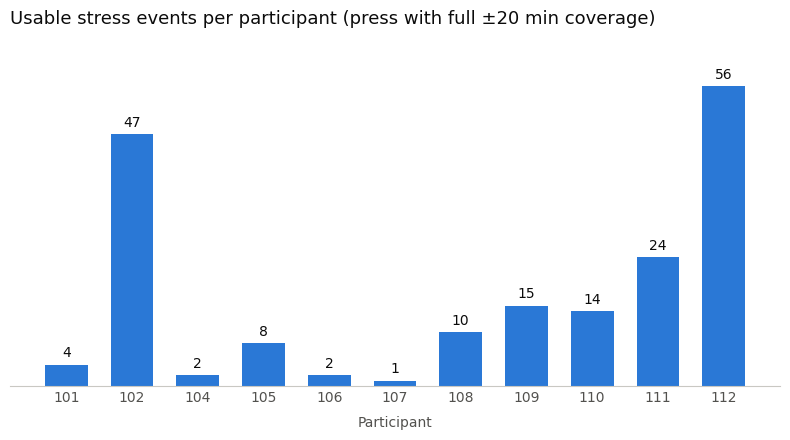

In [6]:
## usable tags per participant
fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.bar(
    coverage.index,
    coverage["stress_events"],
    width=0.65,
    color="#2a78d6",
)

# value on each bar instead of a y axis to read against
ax.bar_label(bars, padding=3, color="#0b0b0b", fontsize=10)

ax.set_title(
    "Usable stress events per participant (press with full ±20 min coverage)",
    color="#0b0b0b",
    fontsize=13,
    pad=12,
    loc="left",
)
ax.set_xlabel("Participant", color="#52514e", labelpad=8)

ax.get_yaxis().set_visible(False)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)

ax.spines["bottom"].set_color("#c9c8c3")
ax.tick_params(axis="x", colors="#52514e", length=0)
ax.margins(y=0.15)

plt.tight_layout()
plt.show()

## 3. Look at the signal around a press

Before trusting the construction, check that a kept tag really has continuous
EDA and HR across its ±20 min, and that a rejected one was rejected for missing
recording rather than a bug.

In [7]:
def plot_tag_context(df, tags, tag_idx, context_min=20, display_min=30, title=None):
    """EDA and HR around one E4 button press.

    context_min: shaded region either side of the tag (ADARP uses ±20 min)
    display_min: how much is drawn either side
    """
    row = tags.iloc[tag_idx]

    tag_time = row["tag_time"]
    session_name = row["session"]

    # slice on time first — filtering all 24M rows by session name is slow
    view = df.loc[tag_time - pd.Timedelta(minutes=display_min):
                  tag_time + pd.Timedelta(minutes=display_min)]
    view = view[view["session"] == session_name]

    context_start = tag_time - pd.Timedelta(minutes=context_min)
    context_end = tag_time + pd.Timedelta(minutes=context_min)

    fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

    panels = [
        (axes[0], view["eda"].dropna(), "EDA (µS)"),
        (axes[1], view["hr"].dropna(), "HR (BPM)"),
    ]

    for ax, signal, label in panels:
        ax.plot(signal.index, signal.values, linewidth=0.8, color="tab:red")
        ax.axvspan(context_start, context_end, alpha=0.15,
                   label=f"±{context_min} min stress context")
        ax.axvline(tag_time, linestyle="--", linewidth=2, label="Button press")
        ax.set_ylabel(label)

    axes[0].set_title(title or f"{session_name} — tag {tag_idx}")
    axes[0].legend()
    axes[1].set_xlabel("UTC time")

    plt.tight_layout()
    plt.show()

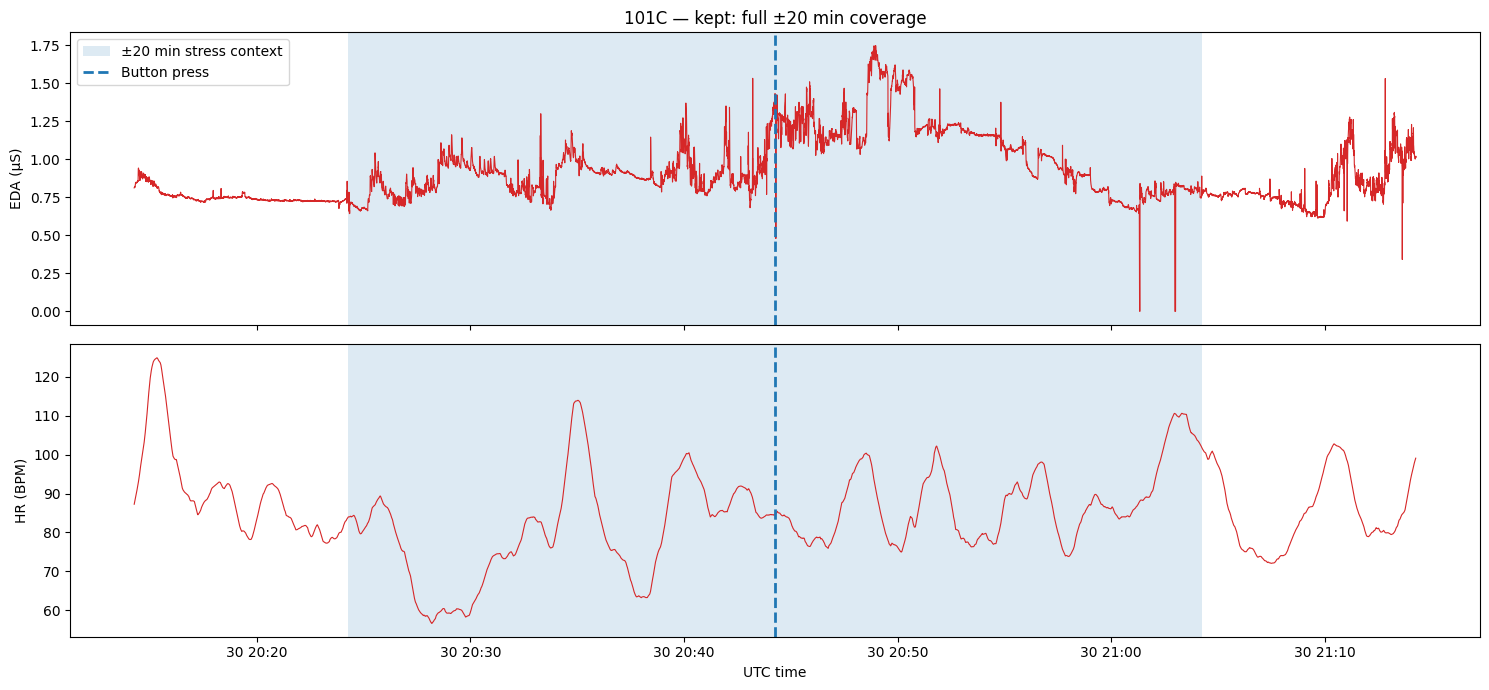

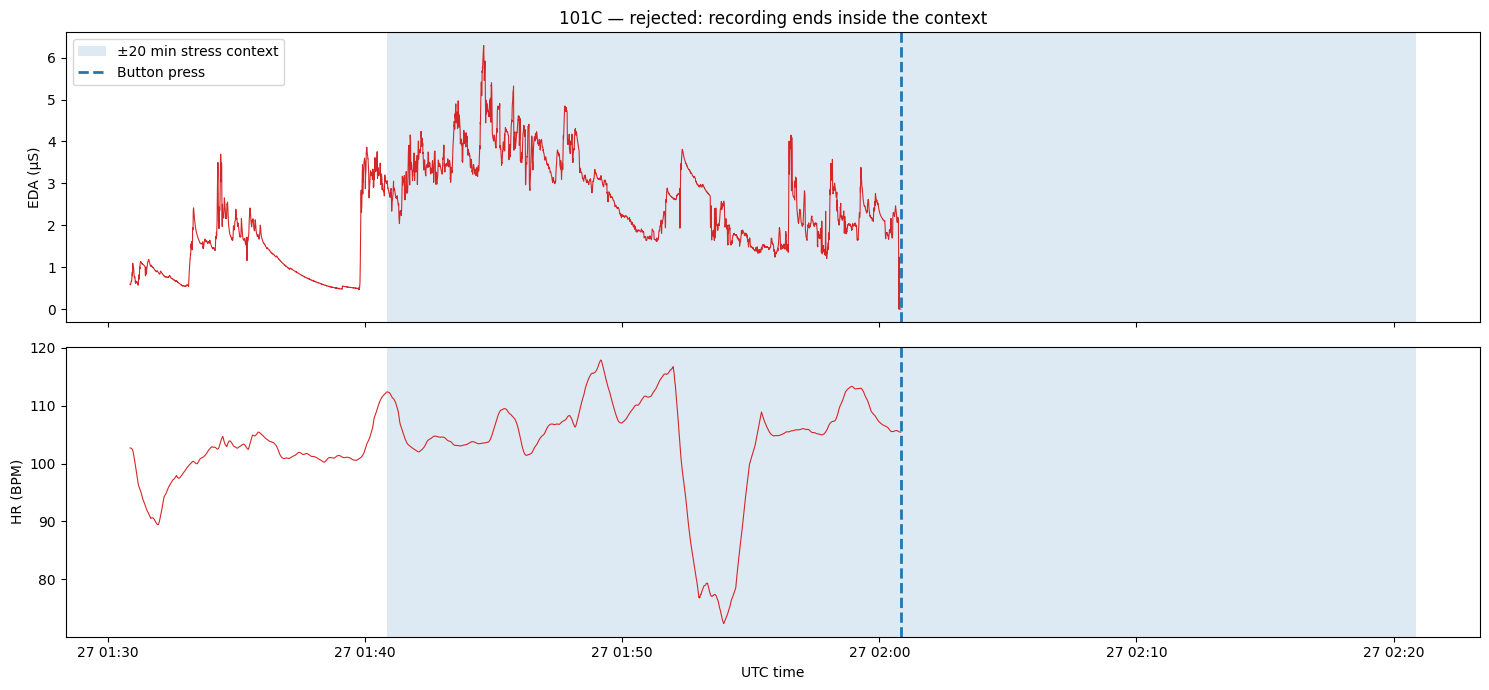

In [8]:
## a kept event and a rejected press, side by side in time
rejected_101 = tags_101[~(tags_101["usable"] & tags_101["full_context"])].reset_index(drop=True)

plot_tag_context(df, events_101, 0, title="101C — kept: full ±20 min coverage")

if len(rejected_101):
    plot_tag_context(df, rejected_101, 0, title="101C — rejected: recording ends inside the context")

## 4. Segments

Two presses less than 40 min apart claim overlapping ±20 min spans. They get two
different treatments:

- **less than a minute apart** — the button hit twice for one moment. Only the
  first press is kept; the repeat is dropped, because there was one annotation.
- **further apart** — separate reported moments during one stressful stretch.
  Both keep their own 40 min segment, since each is its own annotation. The
  signal they share is handled at windowing time instead: the windows both
  segments claim are kept once (§5).

Non-stress is the stricter side: a span only opens once a press's whole ±60 min
window has gone by, so the run-up to a press is discarded rather than counted as
calm, and the buffer applies to **every** press, valid or not — a press that
failed the coverage check still marks a reported stress moment.

Sessions with no press at all contribute whole.

In [9]:
df_101 = df[df["participant"] == "101"]

events_kept_101 = prep.collapse_repeats(events_101)
stress_101 = prep.stress_segments(df_101, events_kept_101)
nonstress_101 = prep.nonstress_segments(df_101, tags_101)

def total_hours(segments):
    return sum(
        (s["frame"].index[-1] - s["frame"].index[0]).total_seconds()
        for s in segments
    ) / 3600

durations = pd.Series([
    (s["frame"].index[-1] - s["frame"].index[0]).total_seconds() / 60
    for s in nonstress_101
])

dropped_101 = len(events_kept_101.attrs["dropped"])

print(f"{len(events_101)} events -> {len(events_kept_101)} after dropping "
      f"{dropped_101} repeat press{'es' if dropped_101 != 1 else ''} "
      f"-> {len(stress_101)} stress segments, one per press")
print(f"{len(nonstress_101)} non-stress segments; duration (min): "
      f"median {durations.median():.0f}, max {durations.max():.0f}, "
      f"total {durations.sum() / 60:.0f} h")

# what discarding the run-up to each press costs
both = prep.nonstress_segments(df_101, tags_101, side="both")
print(f"\nkeeping the pre-press spans too would give {len(both)} segments, "
      f"{total_hours(both):.0f} h vs {total_hours(nonstress_101):.0f} h")

4 events -> 3 after dropping 1 repeat press -> 3 stress segments, one per press
12 non-stress segments; duration (min): median 190, max 683, total 59 h

keeping the pre-press spans too would give 24 segments, 95 h vs 59 h


## 5. Window everything

60 s windows, 30 s stride. What survives is decided by three rules:

- windows sit on **one grid per session**, running from that session's first
  sample, rather than restarting at each tag. The same seconds therefore always
  produce the same window, whichever tag's interval asked for it.
- a window is kept only where it lies wholly inside an interval, and only if
  both modalities can fill it with contiguous samples — 240 EDA and 60 HR.
- a window covered by more than one tag's ±20 min interval enters the dataset
  **once**, identified by participant, session and its own start and end — never
  by comparing sensor values. It carries every covering tag in `event_ids`.

The intervals themselves are never merged: two tags 35 min apart keep two
separate 40 min annotations, and only the windows in their 5 min of overlap are
deduplicated.

In [10]:
eda, hr, meta, per_participant = prep.build_dataset(
    df, tags_by_participant, nonstress_ratio=2, seed=0
)

pool_meta = prep.pool_metadata(per_participant)

print(f"pool:    {len(pool_meta):,} windows — "
      f"{int((pool_meta['label'] == 1).sum()):,} stress, "
      f"{int((pool_meta['label'] == 0).sum()):,} non-stress")
print(f"dataset: {len(meta):,} windows — "
      f"{int((meta['label'] == 1).sum()):,} stress, "
      f"{int((meta['label'] == 0).sum()):,} non-stress "
      f"(1:2, sampled per participant)")
print(f"\nEDA {eda.shape}, HR {hr.shape}, metadata {meta.shape}")

meta.head()

pool:    74,943 windows — 12,206 stress, 62,737 non-stress
dataset: 34,353 windows — 12,206 stress, 22,147 non-stress (1:2, sampled per participant)

EDA (34353, 240), HR (34353, 60), metadata (34353, 14)


,participant,session,segment_type,segment_id,event_id,n_events,session_start,segment_start,segment_end,window_id,window_start,window_end,label,event_ids
0,101,A01f4c_190430-161241,stress,stress_000,event_000,1,2019-04-30 16:12:51+00:00,2019-04-30 20:24:15.600000+00:00,2019-04-30 21:04:15.600000+00:00,stress_000_w0000,2019-04-30 20:24:21+00:00,2019-04-30 20:25:21+00:00,1,event_000
1,101,A01f4c_190430-161241,stress,stress_000,event_000,1,2019-04-30 16:12:51+00:00,2019-04-30 20:24:15.600000+00:00,2019-04-30 21:04:15.600000+00:00,stress_000_w0001,2019-04-30 20:24:51+00:00,2019-04-30 20:25:51+00:00,1,event_000
2,101,A01f4c_190430-161241,stress,stress_000,event_000,1,2019-04-30 16:12:51+00:00,2019-04-30 20:24:15.600000+00:00,2019-04-30 21:04:15.600000+00:00,stress_000_w0002,2019-04-30 20:25:21+00:00,2019-04-30 20:26:21+00:00,1,event_000
3,101,A01f4c_190430-161241,stress,stress_000,event_000,1,2019-04-30 16:12:51+00:00,2019-04-30 20:24:15.600000+00:00,2019-04-30 21:04:15.600000+00:00,stress_000_w0003,2019-04-30 20:25:51+00:00,2019-04-30 20:26:51+00:00,1,event_000
4,101,A01f4c_190430-161241,stress,stress_000,event_000,1,2019-04-30 16:12:51+00:00,2019-04-30 20:24:15.600000+00:00,2019-04-30 21:04:15.600000+00:00,stress_000_w0004,2019-04-30 20:26:21+00:00,2019-04-30 20:27:21+00:00,1,event_000


In [11]:
## every stress window kept, two non-stress drawn for each
sample = prep.sampling_table(meta, per_participant)

print(sample.to_string())
print(f"\n{int(sample['nonstress_kept'].sum()):,} of "
      f"{int(sample['nonstress_available'].sum()):,} non-stress windows drawn")

## a participant whose pool cannot cover 2:1 keeps all of it
short = sample[sample["ratio"] < 2]
if len(short):
    print("\nbelow 2:1, pool exhausted:")
    print(short.to_string())

             stress  nonstress_available  nonstress_kept  ratio   total  total_pool
participant                                                                        
101           234.0               7021.0           468.0   2.00   702.0      7255.0
102          3451.0               5624.0          5624.0   1.63  9075.0      9075.0
104           156.0                  0.0             0.0   0.00   156.0       156.0
105           546.0              10677.0          1092.0   2.00  1638.0     11223.0
106           156.0               6352.0           312.0   2.00   468.0      6508.0
107            78.0               3774.0           156.0   2.00   234.0      3852.0
108           780.0               2582.0          1560.0   2.00  2340.0      3362.0
109          1120.0               1565.0          1565.0   1.40  2685.0      2685.0
110           980.0               6482.0          1960.0   2.00  2940.0      7462.0
111          1522.0               3181.0          3044.0   2.00  4566.0     

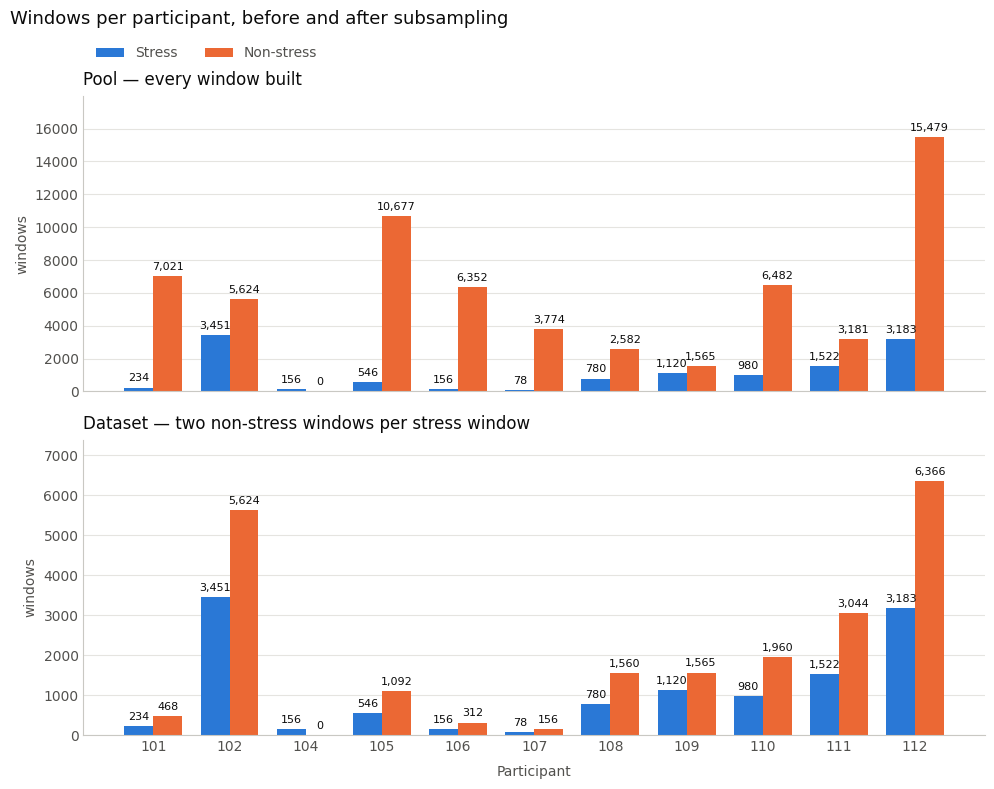

In [12]:
## plot D — the pool and the 1:2 sample drawn from it, one panel each
x = np.arange(len(sample))
width = 0.38

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

panels = [
    (axes[0], "nonstress_available", "Pool — every window built"),
    (axes[1], "nonstress_kept", "Dataset — two non-stress windows per stress window"),
]

for ax, nonstress_column, title in panels:
    # stress is the same in both panels; only the non-stress side is sampled
    stress = ax.bar(x - width / 2, sample["stress"], width,
                    color="#2a78d6", label="Stress")
    nonstress = ax.bar(x + width / 2, sample[nonstress_column], width,
                       color="#eb6834", label="Non-stress")

    for bars in (stress, nonstress):
        ax.bar_label(bars, fmt="{:,.0f}", padding=3, color="#0b0b0b", fontsize=8)

    ax.set_title(title, color="#0b0b0b", fontsize=12, pad=8, loc="left")
    ax.set_ylabel("windows", color="#52514e")

    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)

    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("bottom", "left"):
        ax.spines[side].set_color("#c9c8c3")

    ax.tick_params(axis="both", colors="#52514e", length=0)
    ax.margins(y=0.16)

axes[1].set_xticks(x, sample.index)
axes[1].set_xlabel("Participant", color="#52514e", labelpad=8)

# one legend for both panels, above the first
axes[0].legend(frameon=False, loc="lower left", bbox_to_anchor=(0, 1.08),
               ncols=2, labelcolor="#52514e")

fig.suptitle("Windows per participant, before and after subsampling",
             color="#0b0b0b", fontsize=13, x=0.01, ha="left")

plt.tight_layout()
plt.show()

In [13]:
## what each press contributes, and where two presses annotate one window
stress_meta = pool_meta[pool_meta["label"] == 1]

per_event = (
    stress_meta.groupby(["participant", "event_id"])
    .agg(windows=("window_id", "size"))
)

print(f"{len(per_event)} stress events -> {len(stress_meta):,} windows")
print(f"{int(per_event['windows'].eq(78).sum())} events keep a full interval; "
      f"{int(per_event['windows'].lt(78).sum())} share part of theirs with an "
      f"earlier press")

shared = stress_meta[stress_meta["n_events"] > 1]
print(f"\n{len(shared):,} windows lie inside more than one tag's interval, "
      f"each present once and annotated with all of them:")
print(shared["n_events"].value_counts().sort_index()
      .rename("windows").rename_axis("tags covering").to_string())

print()
print(shared[["participant", "window_start", "event_id", "event_ids"]]
      .head(5).to_string(index=False))

172 stress events -> 12,206 windows
141 events keep a full interval; 31 share part of theirs with an earlier press

1,080 windows lie inside more than one tag's interval, each present once and annotated with all of them:
tags covering
2    967
3     96
4     17

participant              window_start  event_id           event_ids
        102 2019-05-31 23:16:23+00:00 event_004 event_004+event_005
        102 2019-05-31 23:16:53+00:00 event_004 event_004+event_005
        102 2019-05-31 23:17:23+00:00 event_004 event_004+event_005
        102 2019-05-31 23:17:53+00:00 event_004 event_004+event_005
        102 2019-05-31 23:18:23+00:00 event_004 event_004+event_005


In [14]:
## two presses closer than 2 x 20 min claim the same seconds of signal
overlaps = pd.concat(
    [
        prep.overlapping_events(prep.valid_tags(tags)).assign(participant=participant_id)
        for participant_id, tags in tags_by_participant.items()
    ],
    ignore_index=True,
)

repeats = overlaps["gap_min"] < prep.REFRACTORY_S / 60

print(f"{len(overlaps)} overlapping pairs")
print(f"  {repeats.sum():2d} under a minute apart — one moment pressed twice, "
      f"the repeat is dropped")
print(f"  {(~repeats).sum():2d} further apart — separate moments, both kept, "
      f"their shared windows deduplicated")

## what that leaves, per participant
fate = pd.DataFrame({
    participant_id: {
        "events": len(built["events"]) + built["repeats_dropped"],
        "repeats_dropped": built["repeats_dropped"],
        "stress_segments": int(
            built["meta"].loc[built["meta"]["label"] == 1, "segment_id"].nunique()
        ),
        "duplicate_windows_dropped": built["duplicate_windows_dropped"],
    }
    for participant_id, built in per_participant.items()
}).T

print()
print(fate.to_string())

print()
print(overlaps.sort_values("gap_min").head(12).to_string(index=False))


## how long the segments are, and what each length band contributes
## (the pool, before the non-stress side is sampled down)
durations = prep.segment_durations(pool_meta)

print("\n" + prep.duration_table(pool_meta).to_string())

## a segment short of its own window count gave those windows up to an earlier
## overlapping segment
shortfall = durations[durations["windows_lost"] > 0]

print(f"\n{len(shortfall)} of {len(durations)} segments lost windows to an "
      f"earlier overlapping segment: {int(shortfall['windows_lost'].sum()):,} "
      f"windows, {100 * shortfall['windows_lost'].sum() / durations['expected_windows'].sum():.1f}% "
      f"of what the spans allow")

42 overlapping pairs
  11 under a minute apart — one moment pressed twice, the repeat is dropped
  31 further apart — separate moments, both kept, their shared windows deduplicated

     events  repeats_dropped  stress_segments  duplicate_windows_dropped
101       4                1                3                          0
102      47                1               46                        137
104       2                0                2                          0
105       8                1                7                          0
106       2                0                2                          0
107       1                0                1                          0
108      10                0               10                          0
109      15                0               15                         50
110      14                1               13                         34
111      24                2               22                        194
112      56    

In [15]:
## every segment, with the gaps and overlaps around it
#   gap_to_next_min   silence until the next segment of the same session,
#                     negative where the two overlap
#   overlap_next_min  that overlap, as a positive number
#   windows_dropped   windows this segment gave up to an earlier one
segment_gaps = prep.all_segment_gaps(per_participant)

overlapping = segment_gaps[segment_gaps["overlap_next_min"] > 0]

print(f"{len(segment_gaps)} segments, {len(overlapping)} overlapping the next "
      f"segment of their session")
print(f"largest overlap: {segment_gaps['overlap_next_min'].max():.2f} min "
      f"(the bound is 2 x {prep.CONTEXT_MIN} min, beyond which spans no longer "
      f"overlap)")
print(f"{int(segment_gaps['windows_dropped'].sum()):,} windows dropped as "
      f"duplicates in total")

segment_gaps

298 segments, 31 overlapping the next segment of their session
largest overlap: 37.48 min (the bound is 2 x 20 min, beyond which spans no longer overlap)
1,210 windows dropped as duplicates in total


,participant,session,segment_id,segment_type,event_id,n_events,span_min,windows,windows_dropped,gap_to_next_min,overlap_next_min,press_gaps_min,max_press_gap_min
0,101,A01f4c_190429-184613,nonstress_000,nonstress,None,0,189.416667,377,0,NaN,NaN,[],NaN
1,101,A01f4c_190430-034436,nonstress_001,nonstress,None,0,440.866667,880,0,NaN,NaN,[],NaN
2,101,A01f4c_190430-161241,stress_000,stress,event_000,1,40.000000,78,0,40.023333,0.0,[],NaN
3,101,A01f4c_190430-161241,nonstress_002,nonstress,None,0,79.566667,158,0,NaN,NaN,[],NaN
4,101,A01f4c_190430-234943,nonstress_003,nonstress,None,0,190.800000,380,0,NaN,NaN,[],NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
293,112,A02160_200213-171701,nonstress_009,nonstress,None,0,20.875000,40,0,40.001667,0.0,[],NaN
294,112,A02160_200213-171701,stress_030,stress,event_033,1,40.000000,78,0,40.002500,0.0,[],NaN
295,112,A02160_200213-171701,nonstress_010,nonstress,None,0,69.725000,138,0,40.001667,0.0,[],NaN
296,112,A02160_200213-171701,stress_031,stress,event_034,1,40.000000,78,0,40.002500,0.0,[],NaN


## 6. Validation table

In [16]:
table = prep.validation_table(per_participant)

print(table.to_string(formatters={"stress_fraction": "{:.3f}".format}))
print(f"\n{table['total_windows'].sum():,} windows in total, "
      f"overall stress fraction "
      f"{table['stress_windows'].sum() / table['total_windows'].sum():.3f}")

             total_tags  repeat_presses_dropped  duplicate_windows_dropped  usable_stress_events  stress_segments  stress_windows  nonstress_segments  nonstress_windows  total_windows stress_fraction
participant                                                                                                                                                                                            
101                  19                       1                          0                     3                3             234                  12               7021           7255           0.032
102                  86                       1                        137                    46               46            3451                  28               5624           9075           0.380
104                  22                       0                          0                     2                2             156                   0                  0            156           1.000


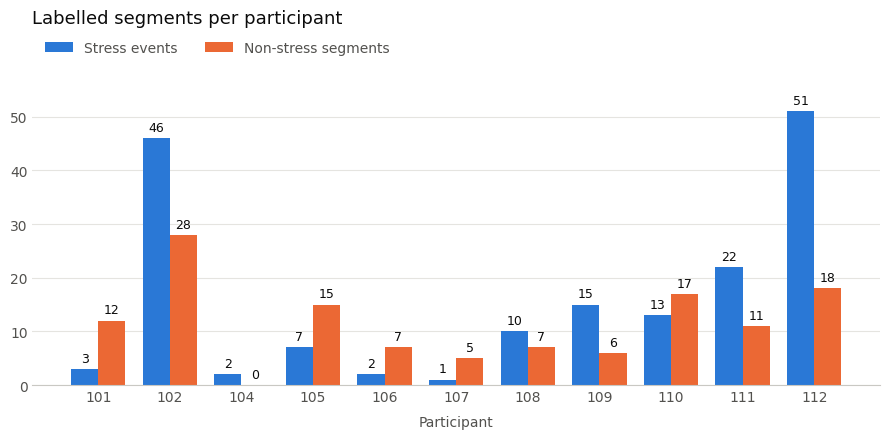

In [17]:
## plot A — labelled examples per participant, before windowing
x = np.arange(len(table))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 4.5))

positives = ax.bar(x - width / 2, table["usable_stress_events"], width,
                   label="Stress events", color="#2a78d6")
negatives = ax.bar(x + width / 2, table["nonstress_segments"], width,
                   label="Non-stress segments", color="#eb6834")

for bars in (positives, negatives):
    ax.bar_label(bars, padding=3, color="#0b0b0b", fontsize=9)

ax.set_title("Labelled segments per participant", color="#0b0b0b",
             fontsize=13, pad=34, loc="left")
ax.set_xlabel("Participant", color="#52514e", labelpad=8)
ax.set_xticks(x, table.index)

# recessive horizontal grid, behind the bars
ax.set_axisbelow(True)
ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)

for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)

ax.spines["bottom"].set_color("#c9c8c3")
ax.tick_params(axis="both", colors="#52514e", length=0)
ax.margins(y=0.15)
# above the plot area: inside it, a tall bar collides with the labels
ax.legend(frameon=False, loc="lower left", bbox_to_anchor=(0, 1.01),
          ncols=2, labelcolor="#52514e")

plt.tight_layout()
plt.show()

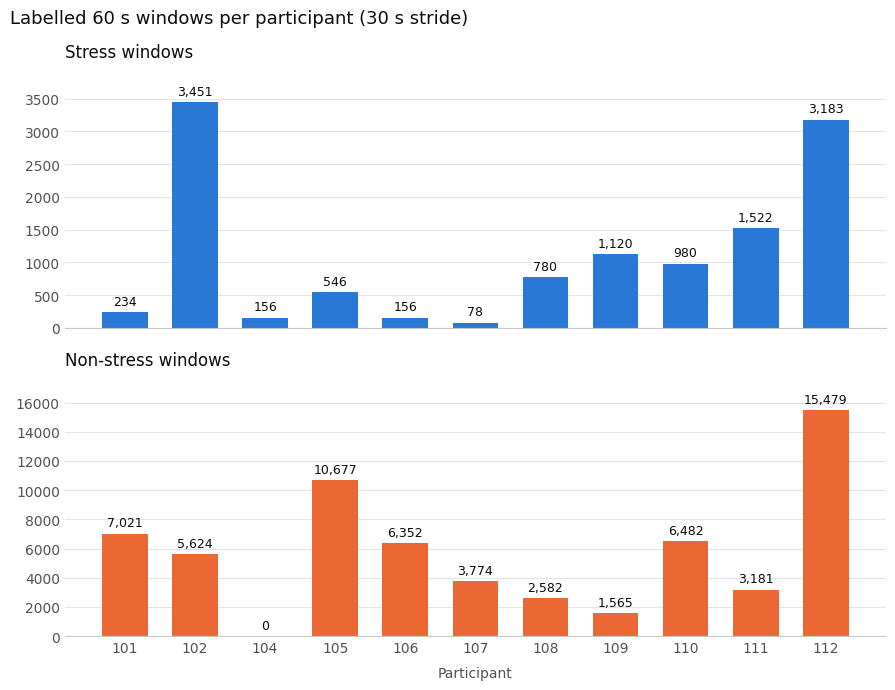

In [18]:
## plot B — windows per participant
# ~10x apart, so two panels rather than one axis where the stress bars vanish
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

panels = [
    (axes[0], "stress_windows", "Stress windows", "#2a78d6"),
    (axes[1], "nonstress_windows", "Non-stress windows", "#eb6834"),
]

for ax, column, label, color in panels:
    bars = ax.bar(table.index, table[column], width=0.65, color=color)
    ax.bar_label(bars, fmt="{:,.0f}", padding=3, color="#0b0b0b", fontsize=9)
    ax.set_title(label, color="#0b0b0b", fontsize=12, pad=8, loc="left")

    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)

    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)

    ax.spines["bottom"].set_color("#c9c8c3")
    ax.tick_params(axis="both", colors="#52514e", length=0)
    ax.margins(y=0.15)

fig.suptitle("Labelled 60 s windows per participant (30 s stride)",
             color="#0b0b0b", fontsize=13, x=0.01, ha="left")
axes[1].set_xlabel("Participant", color="#52514e", labelpad=8)

plt.tight_layout()
plt.show()

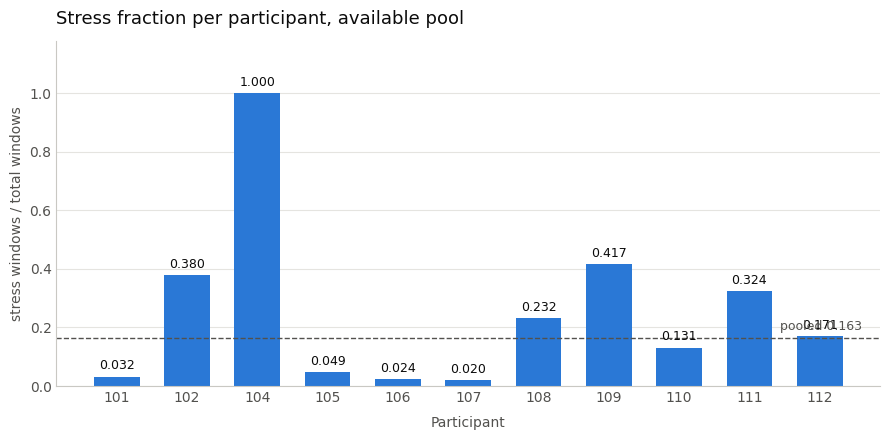

In [19]:
## plot C — class balance, the number that shapes how AL behaves
overall = table["stress_windows"].sum() / table["total_windows"].sum()

fig, ax = plt.subplots(figsize=(9, 4.5))

bars = ax.bar(table.index, table["stress_fraction"], width=0.65, color="#2a78d6")
ax.bar_label(bars, fmt="{:.3f}", padding=3, color="#0b0b0b", fontsize=9)

ax.axhline(overall, color="#52514e", linestyle="--", linewidth=1)
ax.annotate(f"pooled {overall:.3f}", xy=(len(table) - 0.4, overall),
            xytext=(0, 6), textcoords="offset points",
            color="#52514e", fontsize=9, ha="right")

ax.set_title("Stress fraction per participant, available pool", color="#0b0b0b",
             fontsize=13, pad=12, loc="left")
ax.set_xlabel("Participant", color="#52514e", labelpad=8)
ax.set_ylabel("stress windows / total windows", color="#52514e")

ax.set_axisbelow(True)
ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)

for side in ("top", "right"):
    ax.spines[side].set_visible(False)

for side in ("bottom", "left"):
    ax.spines[side].set_color("#c9c8c3")

ax.tick_params(axis="both", colors="#52514e", length=0)
ax.margins(y=0.18)

plt.tight_layout()
plt.show()

## 7. Save the window pool

`processed/adarp_windows.npz` holds the two arrays, `adarp_windows.csv` the
provenance row for row. Everything downstream — the SSL encoder, the splits,
the active-learning runs — reads these rather than re-deriving them.

In [20]:
paths = prep.save_windows("processed/adarp_windows", eda, hr, meta)
table.to_csv("processed/validation_table.csv")
sample.to_csv("processed/sampling_table.csv")
overlaps.to_csv("processed/overlapping_events.csv", index=False)
segment_gaps.to_csv("processed/segment_gaps.csv", index=False)

for path in paths:
    print(path, f"{path.stat().st_size / 1e6:.1f} MB")

processed/adarp_windows.npz 39.2 MB
processed/adarp_windows.csv 7.6 MB
